In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import string
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

from phd_project.config.config import load_config
from phd_project.plotting import custom_log_formatter
from phd_project.scripts.WP1_ground_motion_set.hazard import (
    group_hazard_curves,
    group_disagg_data,
    get_disagg_stats_from_groups)

from phd_project.scripts.oqhelpers import (
    get_bins,
    )

from openquake.commonlib.datastore import read

cfg = load_config()

In [3]:
# TODO:: 
# Prior to running the analyses in this note book the dissagregation analyses
# for the chosen sites need to be run.
# Make sure you have run the PSHA / Dissaggregation defined by the following
# file:

# print(cfg["hazard_models"]["eshm20_AvgSA_sel_sites"])
 

In [3]:
# load the site model and the sites
sel_sites = pd.read_csv(cfg["results"]["selected_sites_csv"])
site_model = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])
site_metadata = pd.concat([sel_sites, site_model], axis=1).T.drop_duplicates().T
site_metadata.columns

Index(['index', 'region', 'seismicity', 'AvgSA', 'nearest_town', 'country',
       'lat', 'lon', 'vs30', 'vs30measured', 'xvf', 'z1pt0', 'z2pt5'],
      dtype='object')

# Plotting Constants

In [4]:
legend_font_params = {'size': 9}
legend_title_font_params = {'weight': 'bold', 'size': 9}

# hazard curve plots
hc_labels = ["High site", "Low/mod site", "Mean - high sites", "Mean - low/mod sites"]
hc_colours = ["r", "g", "r", "g"]
hc_line_styles = ["-", "-", "--", "--"]
hc_alphas = [0.3, 0.3, 1.0, 1.0]

# hc comparison
hc_com_labels = ["AvgSA[0,3] - High", "Low/mod", "Mean - high sites", "Mean - low/mod sites"]
hc_com_colours = ["r", "g", "r", "g"]
hc_com_line_styles = ["-", "-", "--", "--"]

# PSHA Results

## AvgSA[0,3]

In [ ]:
calc_id = 1

try:
    # Load the disaggregation data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_hazard_curves_60sites.pickle"
    with open(fp, "rb") as f:
        grouped_hcs_03 = pickle.load(f)
    
except FileNotFoundError:
    dstore = read(calc_id)
    
    # group the hazard curves by seismicity and region
    groups = list(site_metadata.groupby(["seismicity", "region"]).size().index)
    grouped_hcs_03 = group_hazard_curves(groups, site_metadata, dstore)

    # save the hazard data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_hazard_curves_60sites.pickle"
    with open(fp, "wb") as f:
        pickle.dump(grouped_hcs_03, f)

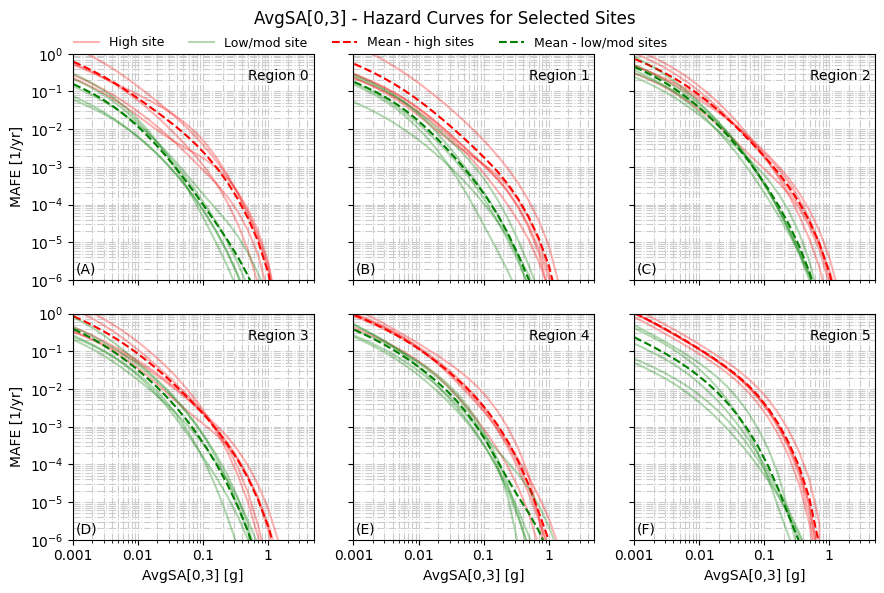

In [6]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        for id, hcs in grouped_hcs_03[(s, r)].items():
            hc = hcs["AvgSA"]["mean"]
            if id == "mean_site":
                ax.loglog(hc[:,0], hc[:,1], ls="--", color=color, label=id)
            else:
                ax.loglog(hc[:,0], hc[:,1], ls="-", color=color, alpha=0.3, label=id)

    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-6, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-6, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA[0,3] [g]")
axs[1,1].set_xlabel("AvgSA[0,3] [g]")
axs[1,2].set_xlabel("AvgSA[0,3] [g]")

handles = [
    mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
    for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = fig.legend(handles=handles,
                 ncols=4, 
                 loc="upper left", 
                 bbox_to_anchor=(0.075, 0.955), 
                #  title="Legend:",
                #  title_fontproperties=legend_title_font_params,
                 prop=legend_font_params,
                 frameon=False)
leg._legend_box.align = "left"

fig.suptitle("AvgSA[0,3] - Hazard Curves for Selected Sites")
fig.tight_layout()

## AvgSA[0,6]

In [7]:
calc_id = 5

try:
    # Load the disaggregation data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_hazard_curves_60sites.pickle"
    with open(fp, "rb") as f:
        grouped_hcs_06 = pickle.load(f)
    
except FileNotFoundError:
    dstore = read(calc_id)
    
    # group the hazard curves by seismicity and region
    groups = list(site_metadata.groupby(["seismicity", "region"]).size().index)
    grouped_hcs_06 = group_hazard_curves(groups, site_metadata, dstore)

    # save the hazard data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_hazard_curves_60sites.pickle"
    with open(fp, "wb") as f:
        pickle.dump(grouped_hcs_06, f)

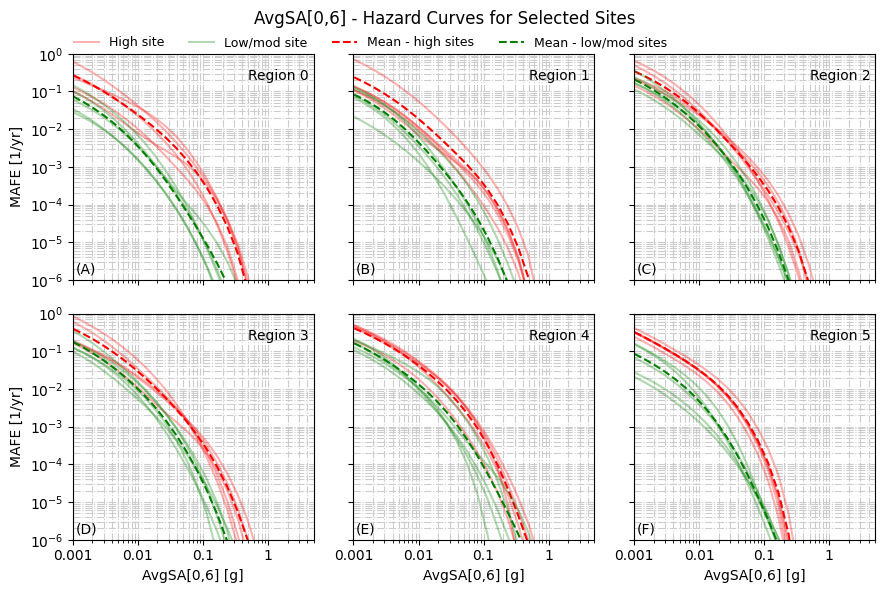

In [8]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        for id, hcs in grouped_hcs_06[(s, r)].items():
            hc = hcs["AvgSA"]["mean"]
            if id == "mean_site":
                ax.loglog(hc[:,0], hc[:,1], ls="--", color=color, label=id)
            else:
                ax.loglog(hc[:,0], hc[:,1], ls="-", color=color, alpha=0.3, label=id)

    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-6, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-6, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA[0,6] [g]")
axs[1,1].set_xlabel("AvgSA[0,6] [g]")
axs[1,2].set_xlabel("AvgSA[0,6] [g]")

handles = [
    mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
    for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = fig.legend(handles=handles,
                 ncols=4, 
                 loc="upper left", 
                 bbox_to_anchor=(0.075, 0.955), 
                #  title="Legend:",
                #  title_fontproperties=legend_title_font_params,
                 prop=legend_font_params,
                 frameon=False)
leg._legend_box.align = "left"

fig.suptitle("AvgSA[0,6] - Hazard Curves for Selected Sites")
fig.tight_layout()

## Comparison

In [9]:
grouped_hcs_06[('high', 0)].keys()


dict_keys([30, 31, 32, 33, 34, 'mean_site'])

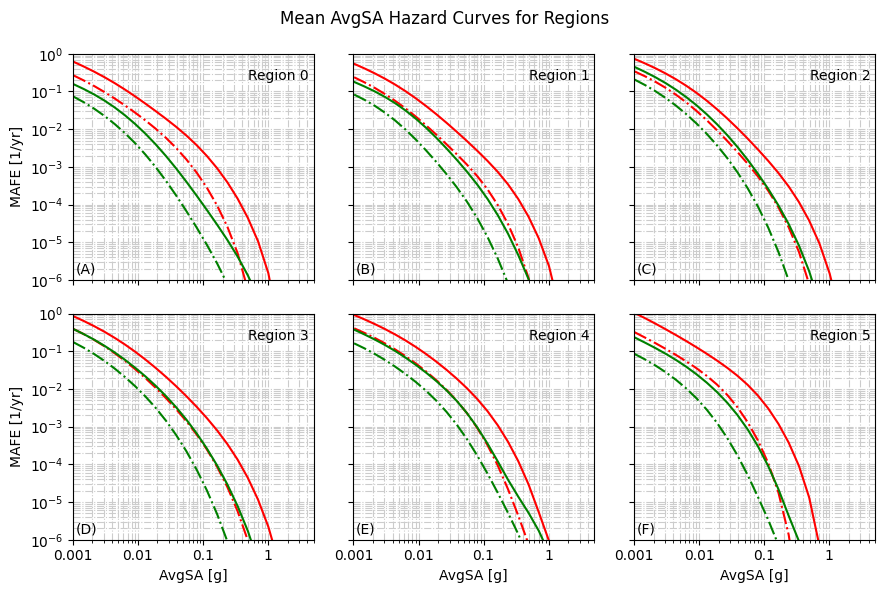

In [10]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        hc_06 = grouped_hcs_06[(s,r)]["mean_site"]["AvgSA"]["mean"]
        hc_03 = grouped_hcs_03[(s,r)]["mean_site"]["AvgSA"]["mean"]

        ax.loglog(hc_03[:,0], hc_03[:,1], ls="-", color=color, label=id)
        ax.loglog(hc_06[:,0], hc_06[:,1], ls="-.", color=color, label=id)


    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-6, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-6, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA [g]")
axs[1,1].set_xlabel("AvgSA [g]")
axs[1,2].set_xlabel("AvgSA [g]")

# handles = [
#     mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
#     for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
# ]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
# leg = fig.legend(handles=handles,
#                  ncols=4, 
#                  loc="upper left", 
#                  bbox_to_anchor=(0.075, 0.955), 
#                 #  title="Legend:",
#                 #  title_fontproperties=legend_title_font_params,
#                  prop=legend_font_params,
#                  frameon=False)
# leg._legend_box.align = "left"

fig.suptitle("Mean AvgSA Hazard Curves for Regions")
fig.tight_layout()

# Disaggregation

## AvgSA[0,3]

In [19]:
calc_id = 3

try:
    # Load the disaggregation data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
    with open(fp, "rb") as f:
        disagg_data_AvgSA_03 = pickle.load(f)

    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"
    with open(fp, "rb") as f:
        disagg_stats_AvgSA_03 = pickle.load(f)
    
except FileNotFoundError:
    dstore = read(calc_id)
    disagg_type = 'TRT_Mag_Dist_Eps'

    bins = get_bins(dstore, disagg_type)
    # get data from datastore and group by seismicity/region
    groups_disagg = group_disagg_data(groups, site_metadata, dstore, 
                                    disagg_type, traditional=True, occurence=True)
    hmaps = dstore["hmaps-stats"]
    disagg_stats = get_disagg_stats_from_groups(groups_disagg, site_metadata,
                                                hmaps, geodf=False)

    # pickle the disaggregation results for later use
    disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
    disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"

    with open(disagg_data_fp, "wb") as file:
        pickle.dump(groups_disagg, file)

    with open(disagg_stats_fp, "wb") as file:
        pickle.dump(disagg_stats, file)

    disagg_data_AvgSA_03 = groups_disagg
    disagg_stats_AvgSA_03 = disagg_stats

In [13]:
# plot the normalised imts
df = disagg_stats_AvgSA_03.pivot(index="site_id", columns="poe", values="imtl")
mafes = [-np.log(1-float(poe)) for poe in df.columns]
normed_imtls = df.to_numpy() / df[0.002103].to_numpy().reshape((-1, 1))
normed_imtls = pd.DataFrame(normed_imtls, index=df.index, columns=df.columns)

grouped_sites = disagg_stats_AvgSA_03.groupby(['seismicity', 'region'])['site_id'].unique()
site_lists = grouped_sites.to_dict()

[]

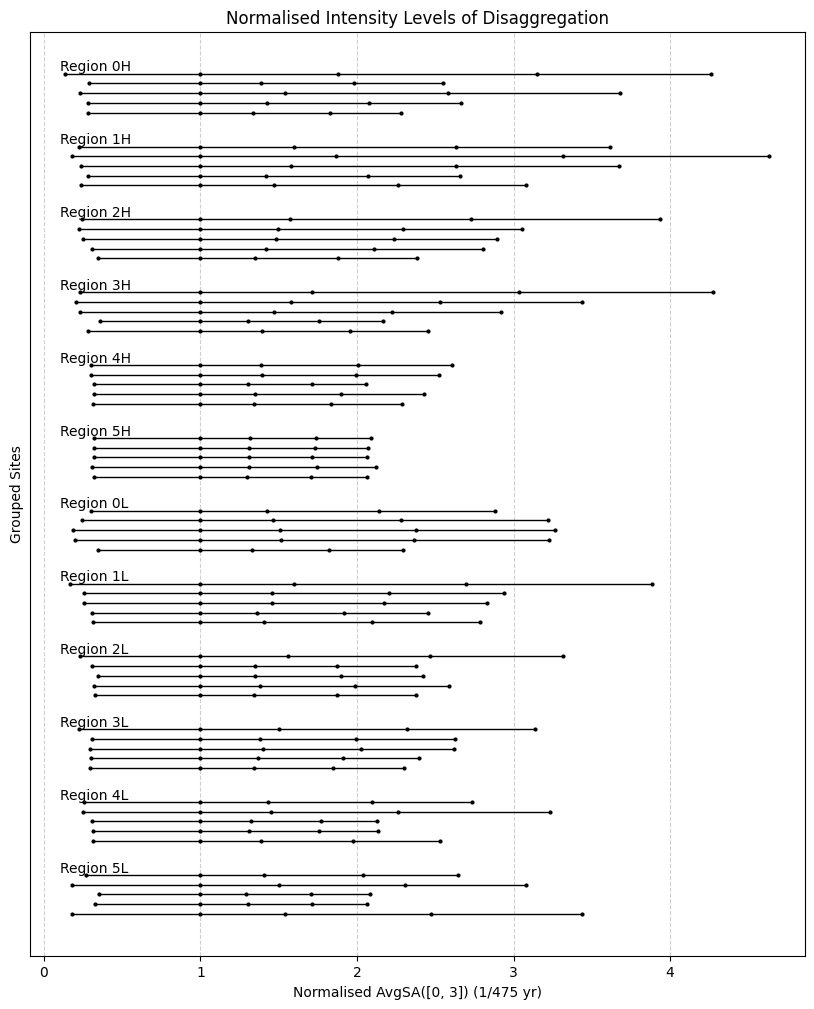

In [14]:
row_spacing = 0.2   # Gap between rows in a group
group_spacing = 1.5 # Gap between different groups

fig, ax = plt.subplots(figsize=(10, 12))

for ii, ((s,r), sites) in enumerate(site_lists.items()):
    for jj, site_id in enumerate(sites):
        imls = normed_imtls.loc[site_id, :]
        
        # Calculate y-coordinate with group offset
        y_pos = (ii * group_spacing) + (jj * row_spacing)

        # Plot horizontal line with dots
        plt.plot(imls, [y_pos] * 5, marker='.', color="k", 
                 linestyle='-', linewidth=1, markersize=4)
        
        if jj == 0:
            ax.text(0.1, y_pos-0.06, f"Region {r}{s.capitalize()[0]}")

ax.set_xlabel("Normalised AvgSA([0, 3]) (1/475 yr)")
ax.set_ylabel("Grouped Sites")
ax.set_title("Normalised Intensity Levels of Disaggregation")
ax.invert_yaxis() # Optional: keep row 0 at the top
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_yticks([])

In [20]:
# Plot a disaggregation plot 

## AvgSA[0,6]

In [20]:
calc_id = 4

try:
    # Load the disaggregation data
    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
    with open(fp, "rb") as f:
        disagg_data_AvgSA_06 = pickle.load(f)

    fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
    with open(fp, "rb") as f:
        disagg_stats_AvgSA_06 = pickle.load(f)
    
except FileNotFoundError:
    dstore = read(calc_id)
    disagg_type = 'TRT_Mag_Dist_Eps'

    bins = get_bins(dstore, disagg_type)
    # get data from datastore and group by seismicity/region
    groups_disagg = group_disagg_data(groups, site_metadata, dstore, 
                                    disagg_type, traditional=True, occurence=True)
    hmaps = dstore["hmaps-stats"]
    disagg_stats = get_disagg_stats_from_groups(groups_disagg, site_metadata,
                                                hmaps, geodf=False)

    # pickle the disaggregation results for later use
    disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
    disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"

    with open(disagg_data_fp, "wb") as file:
        pickle.dump(groups_disagg, file)

    with open(disagg_stats_fp, "wb") as file:
        pickle.dump(disagg_stats, file)

    disagg_data_AvgSA_06 = groups_disagg
    disagg_stats_AvgSA_06 = disagg_stats

In [21]:
disagg_data_AvgSA_06[("high", 0)][31]["AvgSA"][0.019801]

,TRT,Mag,Dist,Eps,Z,"P(X>x|T,m)",nu_m,P(m|X>x),P(m|X=x)
0,Craton,4.625,10.0,-2.5,0.0,0.0,-0.0,-0.0,0.0
1,Craton,4.625,10.0,-1.5,0.0,0.0,-0.0,-0.0,0.0
2,Craton,4.625,10.0,-0.5,0.0,0.0,-0.0,-0.0,0.0
3,Craton,4.625,10.0,0.5,0.0,0.0,-0.0,-0.0,0.0
4,Craton,4.625,10.0,1.5,0.0,0.0,-0.0,-0.0,0.0
...,...,...,...,...,...,...,...,...,...
17095,Volcanic,9.125,490.0,-1.5,0.0,0.0,-0.0,-0.0,0.0
17096,Volcanic,9.125,490.0,-0.5,0.0,0.0,-0.0,-0.0,0.0
17097,Volcanic,9.125,490.0,0.5,0.0,0.0,-0.0,-0.0,0.0
17098,Volcanic,9.125,490.0,1.5,0.0,0.0,-0.0,-0.0,0.0


In [17]:
# plot the normalised imts
df = disagg_stats_AvgSA_06.pivot(index="site_id", columns="poe", values="imtl")
mafes = [-np.log(1-float(poe)) for poe in df.columns]
normed_imtls = df.to_numpy() / df[0.002103].to_numpy().reshape((-1, 1))
normed_imtls = pd.DataFrame(normed_imtls, index=df.index, columns=df.columns)

grouped_sites = disagg_stats_AvgSA_06.groupby(['seismicity', 'region'])['site_id'].unique()
site_lists = grouped_sites.to_dict()

[]

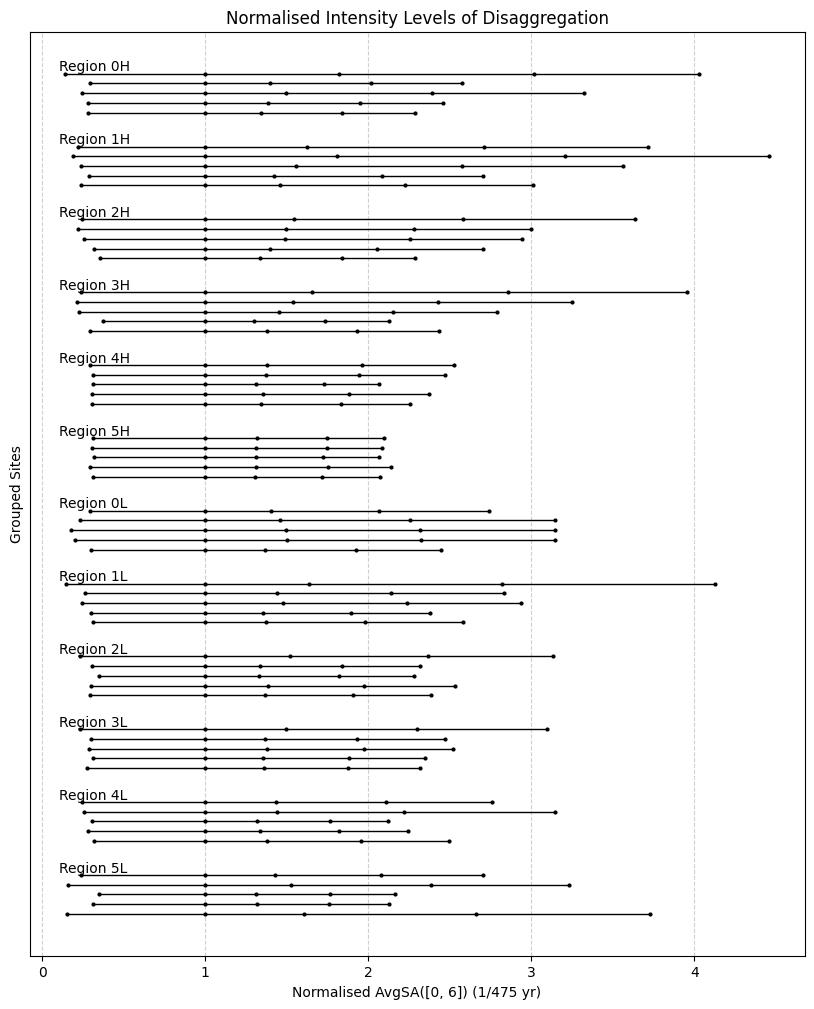

In [18]:
row_spacing = 0.2   # Gap between rows in a group
group_spacing = 1.5 # Gap between different groups

fig, ax = plt.subplots(figsize=(10, 12))

for ii, ((s,r), sites) in enumerate(site_lists.items()):
    for jj, site_id in enumerate(sites):
        imls = normed_imtls.loc[site_id, :]
        
        # Calculate y-coordinate with group offset
        y_pos = (ii * group_spacing) + (jj * row_spacing)

        # Plot horizontal line with dots
        plt.plot(imls, [y_pos] * 5, marker='.', color="k", 
                 linestyle='-', linewidth=1, markersize=4)
        
        if jj == 0:
            ax.text(0.1, y_pos-0.06, f"Region {r}{s.capitalize()[0]}")

ax.set_xlabel("Normalised AvgSA([0, 6]) (1/475 yr)")
ax.set_ylabel("Grouped Sites")
ax.set_title("Normalised Intensity Levels of Disaggregation")
ax.invert_yaxis() # Optional: keep row 0 at the top
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_yticks([])